# Plot scan

In [3]:
import warnings
warnings.filterwarnings("ignore", message="numpy.dtype size changed")
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.append('../Recast/VLFandScalar')
from auxPlots import readContours,label_line
import seaborn as sns
pd.option_context('display.max_columns', -1)

pd.options.mode.chained_assignment = None #Disable copy warnings
# plt.style.use('fivethirtyeight') #Set style
# mpl.rcParams.update({'figure.figsize' : (15,10)})  #Set general plotting options
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})

plt.rcParams.update({"savefig.dpi" : 300}) #Figure resolution


#Define plotting style:
sns.set() #Set style
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.colormaps['RdYlBu']

#### Get contours from different sources

In [4]:


# Direct Searches
directDict = readContours('../Recast/VLFandScalar/SModelS_contours_VLF.csv')
print('Direct Searches=',directDict.keys())

# Direct Searches
directDict_scalar = readContours('../Recast/VLFandScalar/SModelS_contours_scalar.csv')
print('Direct Searches=',directDict_scalar.keys())




Direct Searches= dict_keys([0.67, 1.0])
Direct Searches= dict_keys([(0.67,), (1.0,)])


### Plot Exclusions

In [5]:
# Select contour values:
colors = sns.color_palette('Paired')
plots = {
         'Direct Searches VLF' : {'contour' : 0.67, 'dataDict' : directDict, 'label' : ' VLF', 'textLabel' : None,                              
                              'fill' : True, 'linestyle' : 'solid', 'color' : plt.cm.tab10.colors[2]}, 
          'Direct Searches Scalar' : {'contour' : (0.67,), 'dataDict' : directDict_scalar, 'label' : 'Scalar', 'textLabel' : '', 'textoffset' : -38,                             
                              'fill' : True, 'linestyle' : 'solid', 'color' : plt.cm.tab10.colors[0]}, 

         }

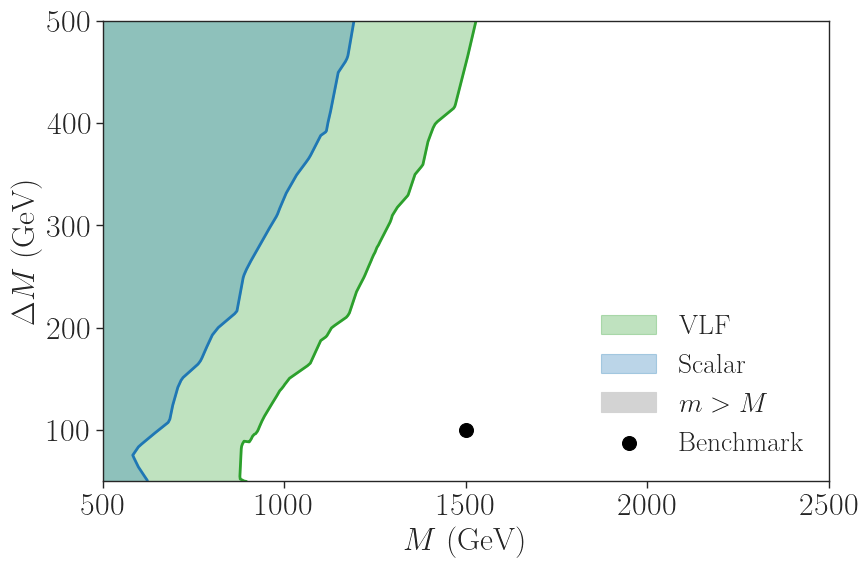

In [15]:
fig = plt.figure(figsize=(9,6))

for p,pInfo in plots.items():
    data = pInfo['dataDict'][pInfo['contour']]
    x = data['mPsiT_GeV']
       
    y = data['deltaM_GeV']
    # if any(x > 450.):
        # y = y[x>450.]
        # x = x[x>450.]
    label = pInfo['label']
    txtLabel = pInfo['textLabel']
    l, = plt.plot(x,y,linewidth=2,color=pInfo['color'],linestyle=pInfo['linestyle'])
    if txtLabel:
        label_line(fig,l, txtLabel, near_y=60.,
                rotation=87.,fontsize=16,
                xmin=200.,offset=(pInfo['textoffset'],0.),boxalpha=0.0)
    
    if pInfo['fill']:
        plt.fill_betweenx(y,x,200,alpha=0.3,color=pInfo['color'], label =pInfo['label'])
        

plt.fill_betweenx([200.,600.],[200.,600.],color='lightgray',alpha=1.0, label = r'$m > M$')
plt.scatter([1500.0], [100.0], marker = 'o', s= 100, edgecolor = 'black', color = 'black', label = 'Benchmark')

# plt.text(210.,400.,r'$m_T < m_{\chi}$',fontsize=17)
plt.hlines(y=10.,xmin=0.,xmax=2000.,colors='white',linewidth=3)
#plt.scatter([1000], [100], )

plt.legend(loc= 'lower right',fontsize=20,framealpha=0)
#plt.yscale('log')
plt.xlabel(r'$M$ (GeV)', fontsize = 23)
plt.ylabel(r'$\Delta M$ (GeV)', fontsize = 23)
plt.xlim(500,2500)
plt.ylim(50,500)
plt.tick_params(axis = 'both', labelsize = 23)
# plt.title('Direct searches LHC constraints', fontsize = 25)
plt.tight_layout()
plt.savefig('direct_searches_vlfscalar.png')
plt.show()